# Lab: Comparing Distributions Across Groups

New York City residents can use 311 to report potholes, cave-ins, failed street repairs, and other street conditions. Comparing the daily volume of these requests can help a city describe where reported demand for street-condition services was greatest.

Use the reproducible analysis workflow:

1. **Question**
2. **Data**
3. **Operation**
4. **Check**
5. **Evidence**
6. **Conclusion**
7. **Limitation**


## Learning goals

- use Pandas datetime and string methods to prepare categories;
- use `groupby()`, `.size()`, and `reset_index()` to create daily counts;
- summarize a quantitative feature within groups;
- compare distributions with histograms, box plots, and violin plots;
- interpret center, spread, shape, overlap, and unusual values; and
- distinguish reported request volume from the underlying number of street problems.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response against the notebook output.

At the end, disclose whether you used AI. If you did, describe one suggestion you evaluated and what you accepted, modified, or rejected. If you did not, state that clearly.


## Dataset

The teaching file contains NYC 311 service requests created during 2025 with the complaint type `Street Condition`. Rows assigned to an unspecified borough were excluded. Each row represents one service request, not one unique street problem.

| Feature | Description |
| --- | --- |
| `request_id` | Identifier assigned to the 311 service request |
| `created_date` | Date and time when 311 created the request |
| `borough` | Borough assigned to the request |
| `descriptor` | More specific kind of street condition |

The file was downloaded from NYC Open Data on August 13, 2026. See `data/README.md` for provenance and preparation details.


# Guided analysis

## Step 1: Question

> **How did the daily number of reported street-condition requests differ across New York City's five boroughs in 2025?**


## Step 2: Data

### Import the libraries

Import Pandas, Matplotlib's `pyplot`, and Seaborn using their conventional aliases.


In [22]:
# Write your code here.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Read the data

Read `data/nyc_311_street_conditions_2025.csv` into a DataFrame named `requests`. Use `parse_dates=["created_date"]` so Pandas converts the CSV's text timestamps into datetime values while loading the file.


In [23]:
# Write your code here.
requests = pd.read_csv("data/nyc_311_street_conditions_2025.csv", parse_dates=["created_date"])

### Preview the data

Display the first and last five rows.


In [24]:
# Write your code here.
display(requests.head())
display(requests.tail())

,request_id,created_date,borough,descriptor
0,63575321,2025-01-01 02:27:33,BROOKLYN,Pothole
1,63585580,2025-01-01 02:31:08,QUEENS,Pothole
2,63590681,2025-01-01 02:39:44,BROOKLYN,Dumpster - Construction Waste
3,63580421,2025-01-01 02:55:52,QUEENS,Pothole
4,63605103,2025-01-01 04:20:00,BROOKLYN,Wear & Tear


,request_id,created_date,borough,descriptor
70193,67353473,2025-12-31 22:26:49,STATEN ISLAND,Pothole
70194,67346881,2025-12-31 22:27:34,STATEN ISLAND,Pothole
70195,67352385,2025-12-31 22:28:43,STATEN ISLAND,Cave-in
70196,67350032,2025-12-31 22:53:19,MANHATTAN,Defective Hardware
70197,67348685,2025-12-31 23:39:14,QUEENS,Pothole


### Inspect the DataFrame

Display its stored data types and missing-value counts.


In [25]:
# Write your code here.
requests.info()
requests.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 70198 entries, 0 to 70197
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   request_id    70198 non-null  int64         
 1   created_date  70198 non-null  datetime64[us]
 2   borough       70198 non-null  str           
 3   descriptor    70198 non-null  str           
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 3.4 MB


request_id      0
created_date    0
borough         0
descriptor      0
dtype: int64

**Complete the table using the data dictionary and your inspection results.** Classify each feature as categorical, quantitative, or temporal.

| Feature | Data type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `request_id` | Categorical | int64 | 0 |
| `created_date` | Temporal | datetime64 | 0 |
| `borough` | Categorical | str | 0 |
| `descriptor` | Categorical | str | 0 |


**What does one row represent?**

Your answer: One individual 311 street-condition service request, not one unique street problem. The same pothole can be reported multiple times, so a row is a report, not a defect.


### Predict


**Which borough do you predict will have the greatest typical number of reported street-condition requests per day? What informed your prediction?**

Your answer: I predict Brooklyn will have the greatest typical number of requests per day. It has a larger populous, and more residents and more street miles should generate more reported street-condition problems. 


## Step 3: Operation


### Make the borough names human-readable

The source stores borough names in all capital letters. **Title case** capitalizes the first letter of each word and writes the remaining letters in lowercase. For example, `STATEN ISLAND` becomes `Staten Island`.

Use `.str.title()` to convert every value in `requests["borough"]` to title case and save the result back into the same feature.


In [26]:
# Write your code here.
requests["borough"] = requests["borough"].str.title()

**What roles do `.str` and `.title()` play in this statement?**

Your answer: ".str" is an accessor that allows you to apply string methods to every value in the series at once. ".title()" is the string method it applies, capitalizing the first letter and making the rest lowercase.


### Create a calendar date

Create `requests["date"]` with `requests["created_date"].dt.normalize()`. The `.dt` accessor opens Pandas' datetime tools, and `.normalize()` sets the time in every value to midnight while preserving its calendar date.


In [27]:
# Write your code here.
requests["date"] = requests["created_date"].dt.normalize()

### Count requests for each borough and date

Create a DataFrame named `daily_requests` with this sequence:

1. group `requests` by `date` and `borough`;
2. use `.size()` to count rows in every group; and
3. use `.reset_index(name="request_count")` to return a DataFrame whose count column is named `request_count`.

Display the first five rows.


In [28]:
# Write your code here.
daily_requests = (requests.groupby(["date", "borough"]).size().reset_index(name="request_count"))
daily_requests.head()

,date,borough,request_count
0,2025-01-01,Bronx,33
1,2025-01-01,Brooklyn,64
2,2025-01-01,Manhattan,14
3,2025-01-01,Queens,70
4,2025-01-01,Staten Island,8


**What does one row of `daily_requests` represent? How is that different from one row of `requests`?**

Your answer: One row of "daily_requests" represents a single borough on a single date, along with the number of requests filed there that day. One row of "requests" represents a single indivivual service request.


**Why did we remove the time before grouping and counting the requests?** As a hint, try repeating the calculation with `created_date` in place of `date` and inspect the result.

Your answer: "created_date" includes a full timestamp down to the second, so grouping by it would put nearly every request in its own group and give a count of about 1. Normalizing to midnight strips time so all the request on the same calendar date fall into one group and get counted together by day.


### Set the borough order

Create `borough_order` containing the five borough names in alphabetical order.


In [29]:
# Write your code here.
borough_order = ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]

### Calculate the mean daily request count

Create `borough_summary` by grouping `daily_requests` by `borough`, selecting `request_count`, calculating the mean, and using `.reindex(borough_order)`.


In [30]:
# Write your code here.
borough_summary = (daily_requests.groupby("borough")["request_count"].mean().reindex(borough_order))
borough_summary

borough
Bronx            19.060274
Brooklyn         50.345205
Manhattan        33.936986
Queens           71.180822
Staten Island    17.800000
Name: request_count, dtype: float64

**Why is comparing only these means incomplete?**

Your answer: Comparing only these means is incomplete because a mean is a single number. It hides how spread out each borough's daily count is, the shape of the distribution, and any unusually high or low days.


## Step 4: Check


### Check borough-date coverage

Count the number of rows for each borough in `daily_requests`, then use `.reindex(borough_order)`.


In [31]:
# Write your code here.
daily_requests["borough"].value_counts().reindex(borough_order)

borough
Bronx            365
Brooklyn         365
Manhattan        365
Queens           365
Staten Island    365
Name: count, dtype: int64

**Does every borough have a count for all 365 dates?**

Your answer: Yes, each borough has a count for all 365 dates.


**What would it mean if one or more boroughs had a count of fewer than 365 rows?**

Your answer: It would mean that borough had a date where zero request came in.


### Check the calculated data

Display missing-value counts for `date`, `borough`, and `request_count`. Then use `.describe()` to summarize `request_count` within each borough and put the boroughs in `borough_order`.


In [32]:
# Write your code here.
print(daily_requests[["date", "borough", "request_count"]].isnull().sum())

daily_requests.groupby("borough")["request_count"].describe().reindex(borough_order)

date             0
borough          0
request_count    0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
borough,,,,,,,,
Bronx,365.0,19.060274,9.238398,1.0,12.0,18.0,25.0,48.0
Brooklyn,365.0,50.345205,21.132529,6.0,33.0,51.0,65.0,113.0
Manhattan,365.0,33.936986,14.683432,2.0,23.0,33.0,43.0,91.0
Queens,365.0,71.180822,30.362103,11.0,47.0,70.0,89.0,215.0
Staten Island,365.0,17.800000,10.095206,1.0,10.0,17.0,24.0,66.0


**Are any calculated values missing or impossible?**

Your answer: No. The missing value counts are zero and each borough's minimum request is at least 1, so there are no impossible values.


**Would a zero necessarily be impossible in another 311 dataset?**

Your answer: No. Any borough could genuinely have zero requests on a given day.


## Step 5: Evidence


### Create overlapping histograms

Use `sns.histplot()` with:

- `data=daily_requests`;
- `x="request_count"`;
- `hue="borough"` and `hue_order=borough_order`;
- `element="step"`;
- layered histograms;
- `alpha=0.45`; and
- the `"deep"` palette.

Capitalize the legend title and add a question-focused title and descriptive axis labels. Label the y-axis `Number of days`.


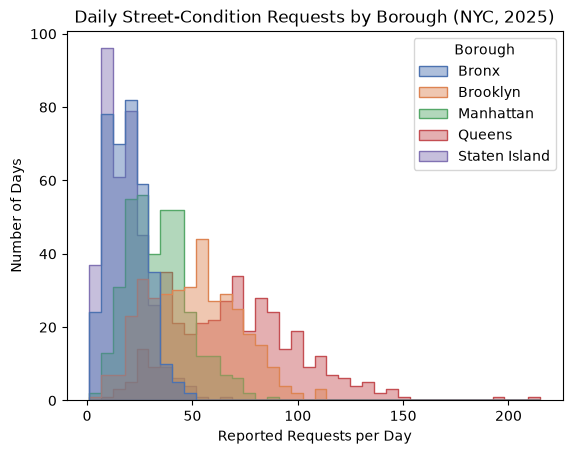

In [33]:
# Write your code here.
ax = sns.histplot(data=daily_requests, x="request_count", hue="borough", hue_order=borough_order, element="step", multiple="layer", alpha=0.45, palette="deep")
ax.set_title("Daily Street-Condition Requests by Borough (NYC, 2025)")
ax.set_xlabel("Reported Requests per Day")
ax.set_ylabel("Number of Days")
ax.get_legend().set_title("Borough")
plt.show()

**What does the histogram reveal, and what makes the boroughs easy or difficult to compare?**

Your answer: The histogram shows that the boroughs sit at clearly different levels. The differences in center are easy to see, but the boroughs are hard to compare where the bars overlap and the colors blend together. Also Queens' wide spread makes the lower count boroughs look a little squished.


### Create a box plot

Put `request_count` on the x-axis and `borough` on the y-axis. Use `borough_order`, the named color `"mediumseagreen"`, and descriptive labels.


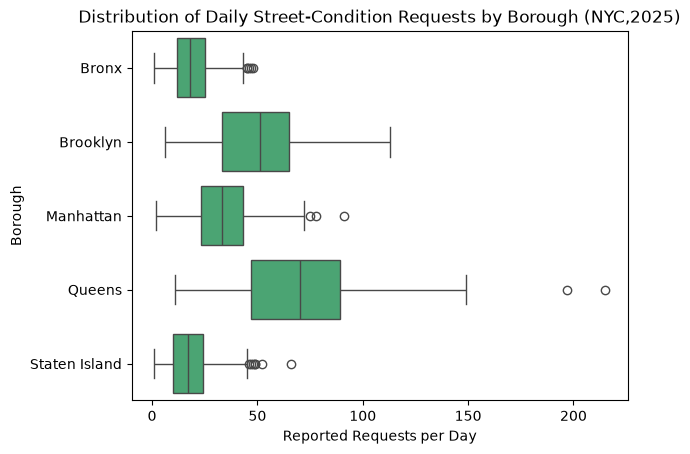

In [34]:
# Write your code here.
ax = sns.boxplot(data=daily_requests, x="request_count", y="borough", order=borough_order, color="mediumseagreen")
ax.set_title("Distribution of Daily Street-Condition Requests by Borough (NYC,2025)")
ax.set_xlabel("Reported Requests per Day")
ax.set_ylabel("Borough")
plt.show()

**What differences among boroughs are easier to see in the box plot than in the histogram?**

Your answer: The bow plot makes it much easier to compare the center and the spread of each borough directly, because the boxes are sepearted instead of overlapping.


### Create a violin plot

Use the same x feature, y feature, and order. Change only the plot color to `"mediumpurple"` in addition to the required data mappings and order.


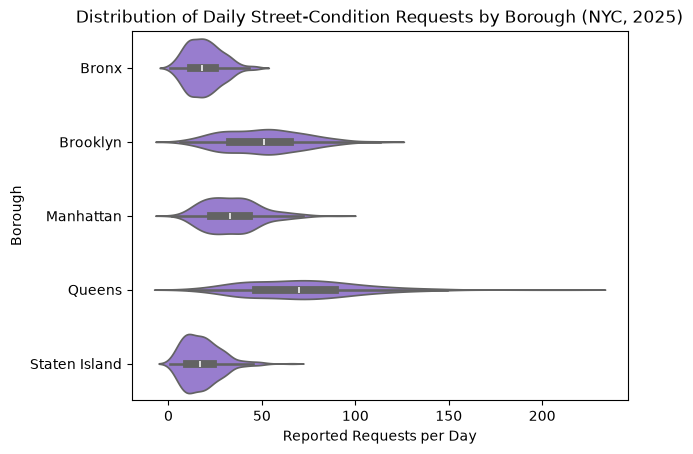

In [35]:
# Write your code here.
ax = sns.violinplot(data=daily_requests, x="request_count", y="borough", order=borough_order, color="mediumpurple")
ax.set_title("Distribution of Daily Street-Condition Requests by Borough (NYC, 2025)")
ax.set_xlabel("Reported Requests per Day")
ax.set_ylabel("Borough")
plt.show()

**What does the violin plot add to the comparison?**

Your answer: The violin plot adds the shape of each each borough's distribution on top of the box plot summary.


**Which of the three figures most clearly compares daily request counts among boroughs? Explain your choice.**

Your answer: The box plot most clearly compares the boroughs. This is because the the boxes are seperate rather than overlapping, it is easy to line up the medians and see the ranking, judge each borough's spread, and spot outliers and attribute them to the right borough.


## Step 6: Conclusion


**What conclusion about borough differences is supported by the 2025 data?**

Your answer: In 2025, the boroughs differed clearly in their typical daily volume of reported street-condition requests.


## Step 7: Limitation


**Why do these request counts not directly measure the number of street problems or borough performance?**

Your answer: The counts only measure the reported requests. They don't actually show the street problems or how well the borough is maintained. The reports depend on things like population size and how many residents actually know about and use the 311.


# Your own analysis

Develop a new research question using the 311 data. Your question must compare a **quantitative feature across categorical groups**. You will probably need to calculate the quantitative feature from the original request records.

Possible grouping features include `descriptor`, month, or day of the week. You may use another meaningful categorical feature that you can create and explain.


## Step 1: Question


**Write a research question that compares a quantitative feature across categorical groups.**

Your answer: How did the daily number of reported street-condition requests differ across days of the week in NYC in 2025?


## Step 2: Data


**Which original features will you use, and what will each row of your calculated DataFrame represent?**

Your answer: I will use "created_date" to derive the day of the week, and I will count requests to get a daily total.


## Step 3: Operation

Prepare the grouping feature, calculate the quantitative feature, and save the resulting DataFrame with a meaningful name.


In [36]:
# Write your code here.
daily_totals = (requests.groupby("date").size().reset_index(name="request_count"))

daily_totals["day_of_week"] = daily_totals["date"].dt.day_name()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

daily_totals.head()

,date,request_count,day_of_week
0,2025-01-01,189,Wednesday
1,2025-01-02,240,Thursday
2,2025-01-03,136,Friday
3,2025-01-04,110,Saturday
4,2025-01-05,155,Sunday


**Briefly explain how your code produced the quantitative feature and comparison groups.**

Your answer: I grouped the individual requests by calendar date and counted them with ".size()" to produce the "request_count" which is the total number of requests filed each day. I then created the comparison groups by extracting each date's weekday name with ".dt.day_name()" so every daily total is labeled with the day of the week it falls on.


## Step 4: Check

Check the calculated data for missing or impossible values, confirm that the intended groups are present, and use an appropriate numerical summary to inspect the distributions.


In [37]:
# Write your code here.
print(daily_totals.isnull().sum())

daily_totals.groupby("day_of_week")["request_count"].describe().reindex(day_order)

date             0
request_count    0
day_of_week      0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
day_of_week,,,,,,,,
Monday,52.0,226.384615,58.222748,96.0,194.75,217.0,258.00,408.0
Tuesday,52.0,240.750000,53.614775,101.0,208.50,243.0,274.25,362.0
Wednesday,53.0,236.886792,57.224477,104.0,194.00,234.0,274.00,426.0
Thursday,52.0,223.115385,56.400756,40.0,192.75,216.0,265.25,330.0
Friday,52.0,183.653846,55.178457,63.0,144.00,177.5,217.25,308.0
Saturday,52.0,111.519231,28.413260,60.0,91.75,110.0,128.25,178.0
Sunday,52.0,123.096154,29.658355,57.0,104.75,124.0,146.25,186.0


**What did your checks establish?**

Your answer: No missing values, all seven weekdays present with 52 to 53 dates each, and no zero or negative counts. Weekdays average around 220 to 240 requests, while weekends drop to about 110 to 125.


## Step 5: Evidence

Create a histogram, box plot, or violin plot that directly addresses your question. Include a clear title and descriptive axis labels.


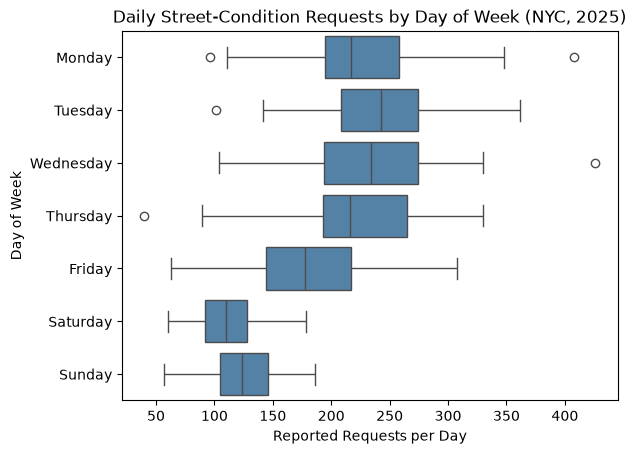

In [38]:
# Write your code here.
ax = sns.boxplot(data=daily_totals, x="request_count", y="day_of_week", order=day_order, color="steelblue")

ax.set_title("Daily Street-Condition Requests by Day of Week (NYC, 2025)")
ax.set_xlabel("Reported Requests per Day")
ax.set_ylabel("Day of Week")
plt.show()

**What pattern in the figure provides the strongest evidence for your answer?**

Your answer: The weekday boxes sit clearly to the right of the weekend boxes, with barely any overlap between the weekday and weekend ranges.


## Step 6: Conclusion


**State one conclusion that directly answers your research question.**

Your answer: Reported street-condition requests were noticeably higher on weekdays than weekends in 2025.


## Step 7: Limitation


**State one important limitation on how your result should be interpreted.**

Your answer: This measures when requests were reported, not when problems occured. Fewer weekend reports likely reflect reporting behavior, not fewer actual street problems.


## AI-use reflection


State whether you used an AI tool. If you did, identify one suggestion you checked and explain what you accepted, modified, or rejected. If you did not, state that clearly.

Your answer: Yes I used Claude AI to check my code and talk through the written answers. One suggestion I checked was setting the histogram legend title with "get_legend().set_title" instead of rebuilding the legend; I accepted it because rebuilding can put the legend out of order with the plotted bars. I verified every number in my answers against the notebook output myself.


## Submission checklist

- Run every code cell from top to bottom.
- Use all requested object and feature names.
- Complete every written-response cell.
- Check that numerical claims match the output.
- Use named colors and audience-friendly labels.
- Compare center, spread, shape, overlap, and unusual values.
- Distinguish reported request volume from actual street conditions or city performance.
- Complete the AI-use reflection.
